In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import h5py
import timm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
train_path = "/content/drive/MyDrive/morph_project/processed/train.h5"
test_path  = "/content/drive/MyDrive/morph_project/processed/test.h5"

with h5py.File(train_path, "r") as f:
    X = np.array(f["X"])
    y = np.array(f["y"])

with h5py.File(test_path, "r") as f:
    X_test = np.array(f["X"])
    y_test = np.array(f["y"])

print("Train:", X.shape, y.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (7177, 224, 224, 3) (7177,)
Test: (1803, 224, 224, 3) (1803,)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
img_size = 224

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


In [8]:
class H5Dataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)


In [9]:
train_dataset = H5Dataset(X_train, y_train, transform)
val_dataset   = H5Dataset(X_val,   y_val,   transform)
test_dataset  = H5Dataset(X_test,  y_test,  transform)


In [10]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2)


In [11]:
class ConvNeXtV2Classifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.2):
        super().__init__()

        self.backbone = timm.create_model(
            "convnextv2_tiny",
            pretrained=True,
            num_classes=0
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)


In [12]:
model = ConvNeXtV2Classifier().to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()


In [14]:
criterion = FocalLoss(alpha=0.25, gamma=2.0)


In [15]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.9)


In [ ]:
epochs = 15

train_losses, val_losses = [], []
train_accs, val_accs = [], []

def accuracy(outputs, labels):
    preds = torch.argmax(outputs, dim=1)
    return (preds == labels).float().mean().item()

best_val_acc = 0
best_path = "/content/drive/MyDrive/morph_project/convnextv2_best.pth"

for epoch in range(epochs):
    model.train()
    tr_loss, tr_acc = 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)   # <-- FOCAL LOSS USED HERE

        loss.backward()
        optimizer.step()

        tr_loss += loss.item()
        tr_acc += accuracy(outputs, labels)

    train_losses.append(tr_loss / len(train_loader))
    train_accs.append(tr_acc / len(train_loader))

    # Validation
    model.eval()
    v_loss, v_acc = 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            v_loss += loss.item()
            v_acc += accuracy(outputs, labels)

    val_losses.append(v_loss / len(val_loader))
    val_accs.append(v_acc / len(val_loader))

    # Save best model
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), best_path)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"| Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} "
          f"| Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")


Epoch [1/15] | Train Loss: 0.0305 | Train Acc: 0.8217 | Val Loss: 0.0286 | Val Acc: 0.8306
Epoch [2/15] | Train Loss: 0.0285 | Train Acc: 0.8309 | Val Loss: 0.0266 | Val Acc: 0.8333
Epoch [3/15] | Train Loss: 0.0259 | Train Acc: 0.8377 | Val Loss: 0.0266 | Val Acc: 0.8326
Epoch [4/15] | Train Loss: 0.0239 | Train Acc: 0.8519 | Val Loss: 0.0265 | Val Acc: 0.8382
Epoch [5/15] | Train Loss: 0.0205 | Train Acc: 0.8701 | Val Loss: 0.0280 | Val Acc: 0.8389
Epoch [6/15] | Train Loss: 0.0170 | Train Acc: 0.8920 | Val Loss: 0.0298 | Val Acc: 0.8319
Epoch [7/15] | Train Loss: 0.0144 | Train Acc: 0.9077 | Val Loss: 0.0392 | Val Acc: 0.8116
Epoch [8/15] | Train Loss: 0.0127 | Train Acc: 0.9211 | Val Loss: 0.0377 | Val Acc: 0.8241
Epoch [9/15] | Train Loss: 0.0109 | Train Acc: 0.9298 | Val Loss: 0.0353 | Val Acc: 0.8053
Epoch [10/15] | Train Loss: 0.0097 | Train Acc: 0.9406 | Val Loss: 0.0457 | Val Acc: 0.8264
Epoch [11/15] | Train Loss: 0.0086 | Train Acc: 0.9488 | Val Loss: 0.0422 | Val Acc: 0.82

In [17]:
best_model = ConvNeXtV2Classifier().to(device)
best_model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/convnextv2_best.pth"))
best_model.eval()

print("Best ConvNeXt-V2 model loaded successfully!")


Best ConvNeXt-V2 model loaded successfully!


In [18]:
all_preds = []
all_labels = []

best_model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = best_model(imgs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n===== Classification Report =====")
print(classification_report(all_labels, all_preds, digits=4))

print("\n===== Confusion Matrix =====")
print(confusion_matrix(all_labels, all_preds))



===== Classification Report =====
              precision    recall  f1-score   support

           0     0.8645    0.9684    0.9135      1489
           1     0.6519    0.2803    0.3920       314

    accuracy                         0.8486      1803
   macro avg     0.7582    0.6243    0.6528      1803
weighted avg     0.8275    0.8486    0.8227      1803


===== Confusion Matrix =====
[[1442   47]
 [ 226   88]]


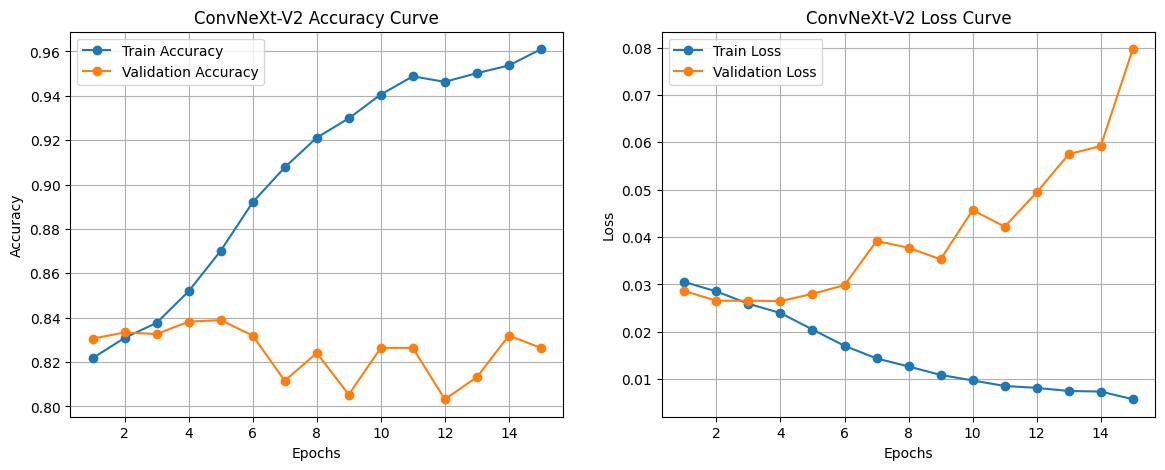

In [19]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14,5))

# ACCURACY
plt.subplot(1,2,1)
plt.plot(epochs_range, train_accs, marker='o', label="Train Accuracy")
plt.plot(epochs_range, val_accs, marker='o', label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ConvNeXt-V2 Accuracy Curve")
plt.legend()
plt.grid(True)===== Classification Report =====
              precision    recall  f1-score   support

           0     0.8645    0.9684    0.9135      1489
           1     0.6519    0.2803    0.3920       314

    accuracy                         0.8486      1803
   macro avg     0.7582    0.6243    0.6528      1803
weighted avg     0.8275    0.8486    0.8227      1803


===== Confusion Matrix =====
[[1442   47]
 [ 226   88]]



# LOSS
plt.subplot(1,2,2)
plt.plot(epochs_range, train_losses, marker='o', label="Train Loss")
plt.plot(epochs_range, val_losses, marker='o', label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ConvNeXt-V2 Loss Curve")
plt.legend()
plt.grid(True)

plt.show()


In [30]:
from google.colab import files
from PIL import Image

def predict_user_image(model, img_path):
    img = Image.open(img_path).convert("RGB")

    transform_inference = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])

    img_tensor = transform_inference(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, 1).item()

    classes = ["Licit", "Illicit"]
    print("\nImage:", img_path)
    print("Prediction:", classes[pred])
    print("Confidence:", round(float(probs[0][pred]), 4))

# Upload and test images
uploaded = files.upload()

for filename in uploaded.keys():
    predict_user_image(best_model, filename)


Saving casias2.png to casias2 (1).png

Image: casias2 (1).png
Prediction: Illicit
Confidence: 0.5238


In [21]:
import torch, timm, h5py
from torchvision import transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size = 224


In [22]:
class ConvNeXtV2Classifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.2):
        super().__init__()
        self.backbone = timm.create_model(
            "convnextv2_tiny",
            pretrained=False,
            num_classes=0
        )
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)


In [23]:
best_model = ConvNeXtV2Classifier().to(device)
best_model.load_state_dict(torch.load("/content/drive/MyDrive/morph_project/convnextv2_best.pth"))
best_model.eval()


ConvNeXtV2Classifier(
  (backbone): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (mlp): GlobalResponseNormMlp(
              (fc1): Linear(in_features=96, out_features=384, bias=True)
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (grn): GlobalResponseNorm()
              (fc2): Linear(in_features=384, out_features=96, bias=True)
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): Conv

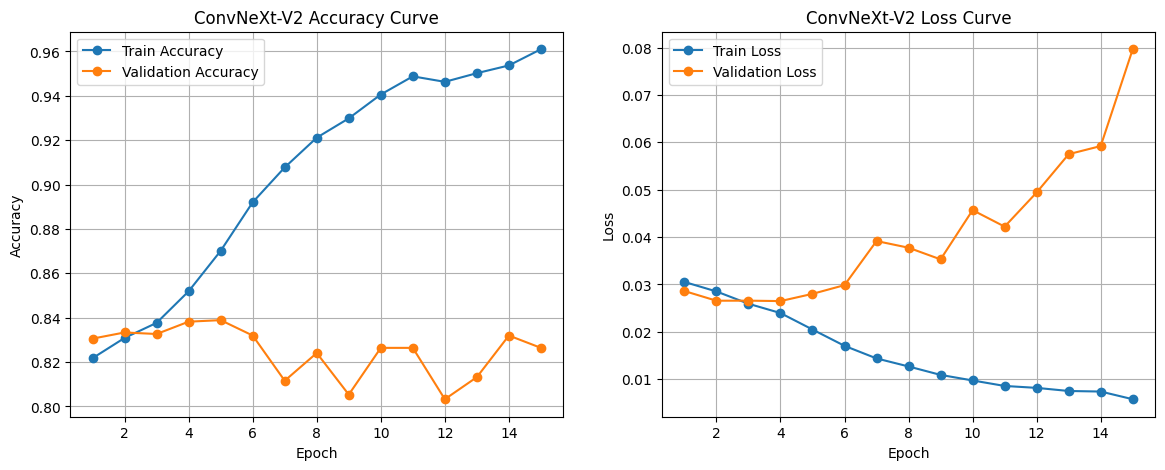

In [31]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

# ==========================
#     ACCURACY CURVE
# ==========================
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accs, marker='o', label="Train Accuracy")
plt.plot(epochs_range, val_accs, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ConvNeXt-V2 Accuracy Curve")
plt.grid(True)
plt.legend()

# ==========================
#       LOSS CURVE
# ==========================
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, marker='o', label="Train Loss")
plt.plot(epochs_range, val_losses, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ConvNeXt-V2 Loss Curve")
plt.grid(True)
plt.legend()

plt.show()
